In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import torch
from torch.utils.data import Dataset, DataLoader

In [2]:
file_path = r'C:\Users\sharif\Desktop\Final5.xlsx'
df = pd.read_excel(file_path)
df.head()

,"STREAMS(""METHANOL"").F","STREAMS(""METHANOL"").T","STREAMS(""METHANOL"").P","STREAMS(""FV"").F","STREAMS(""FV"").T","STREAMS(""FV"").P","STREAMS(""FV"").Zmn(""1-BUT-01"")","STREAMS(""FV"").Zmn(""ISOBU-01"")","STREAMS(""P1"").F","STREAMS(""P1"").T",...,"BLOCKS(""RDCOLUMN"").Stage(4).T","BLOCKS(""RDCOLUMN"").Stage(5).T","BLOCKS(""RDCOLUMN"").Stage(6).T","BLOCKS(""RDCOLUMN"").Stage(7).T","BLOCKS(""RDCOLUMN"").Stage(8).T","BLOCKS(""RDCOLUMN"").Stage(9).T","BLOCKS(""RDCOLUMN"").Stage(10).T","BLOCKS(""RDCOLUMN"").Stage(11).T","STREAMS(""P1"").Zmn(""1-BUT-01"")","STREAMS(""P2"").Zmn(""METHY-01"")"
0,712.082,46.85,1.01325,1965.0,178.574,12.1592,0.64,0.36,1340.14,76.3314,...,105.113,115.106,120.103,122.286,123.236,123.67,123.896,128.634,0.936555,0.965974
1,712.082,46.85,1.01325,1965.0,178.574,12.1592,0.64,0.36,1340.14,76.3314,...,105.113,115.106,120.103,122.286,123.236,123.67,123.896,128.634,0.936555,0.965974
2,712.082,46.85,1.01325,1965.0,178.574,12.1592,0.64,0.36,1340.14,76.3314,...,105.113,115.106,120.103,122.286,123.236,123.67,123.896,128.634,0.936555,0.965974
3,712.082,46.85,1.01325,1965.0,178.574,12.1592,0.64,0.36,1340.14,76.3314,...,105.113,115.106,120.103,122.286,123.236,123.67,123.896,128.634,0.936555,0.965974
4,712.082,46.85,1.01325,1965.0,178.574,12.1592,0.64,0.36,1340.14,76.3313,...,105.113,115.106,120.103,122.286,123.236,123.67,123.896,128.634,0.936555,0.965974


In [3]:
x = df.iloc[:, :-2].values
y = df.iloc[:, -2:].values 

In [4]:
scaler_x = StandardScaler()
scaler_y = StandardScaler()
x = scaler_x.fit_transform(x)
y = scaler_y.fit_transform(y)

In [5]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [6]:
import torch.nn as nn
import math

class MyDataset(Dataset):
    def __init__(self, X, y, seq_len):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
        self.seq_len = seq_len

    def __len__(self):
        return self.X.shape[0] - self.seq_len + 1

    def __getitem__(self, idx):
        x_seq = self.X[idx:idx + self.seq_len, :]
        y_seq = self.y[idx + self.seq_len - 1, :]
        return x_seq, y_seq

In [7]:
class VALSTM(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super().__init__()
        self.W = nn.Parameter(torch.Tensor(input_dim, hidden_dim * 4))
        self.U = nn.Parameter(torch.Tensor(hidden_dim, hidden_dim * 4))
        self.bias = nn.Parameter(torch.Tensor(hidden_dim * 4))

        self.Wa = nn.Parameter(torch.Tensor(input_dim, input_dim))
        self.Ua = nn.Parameter(torch.Tensor(hidden_dim * 2, input_dim))
        self.ba = nn.Parameter(torch.Tensor(input_dim))
        self.Va = nn.Parameter(torch.Tensor(input_dim, input_dim))
        self.softmax = nn.Softmax(dim=1)

        self.fc = nn.Linear(hidden_dim, output_dim)
        self.hidden_dim = hidden_dim
        self.init_weights()

    def init_weights(self):
        stdv = 1.0 / math.sqrt(self.hidden_dim)
        for w in self.parameters():
            w.data.uniform_(-stdv, stdv)

    def forward(self, x):
        batch, seq_len, _ = x.size()
        h_t = torch.zeros(batch, self.hidden_dim).to(x.device)
        c_t = torch.zeros(batch, self.hidden_dim).to(x.device)
        hidden_seq = []
        for t in range(seq_len):
            x_t = x[:, t, :]
            attn = torch.tanh(x_t @ self.Wa + torch.cat([h_t, c_t], dim=1) @ self.Ua + self.ba) @ self.Va
            alpha = self.softmax(attn)
            x_t = alpha * x_t
            gates = x_t @ self.W + h_t @ self.U + self.bias
            i, f, g, o = torch.sigmoid(gates[:, :self.hidden_dim]), torch.sigmoid(gates[:, self.hidden_dim:2*self.hidden_dim]), torch.tanh(gates[:, 2*self.hidden_dim:3*self.hidden_dim]), torch.sigmoid(gates[:, 3*self.hidden_dim:])
            c_t = f * c_t + i * g
            h_t = o * torch.tanh(c_t)
            hidden_seq.append(h_t.unsqueeze(0))
        hidden_seq = torch.cat(hidden_seq, dim=0).transpose(0,1)
        final = hidden_seq[:, -1, :]
        out = self.fc(final)
        return out, alpha

In [8]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
seq_len = 20
batch_size = 64
epochs = 150
input_dim = x.shape[1]
hidden_dim = 64
output_dim = 2

In [9]:
train_ds = MyDataset(x_train, y_train, seq_len)
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)

In [10]:
model = VALSTM(input_dim=input_dim, hidden_dim=hidden_dim, output_dim=output_dim).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.MSELoss()

In [11]:
train_losses = []
test_losses = []

In [12]:
for epoch in range(epochs):
    model.train()
    total_loss = 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        pred, _ = model(xb)
        loss = criterion(pred, yb)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    
    avg_train_loss = total_loss / len(train_loader)
    train_losses.append(avg_train_loss)
    
    x_test_seq = []
    for i in range(len(x_test) - seq_len + 1):
        x_test_seq.append(x_test[i:i+seq_len, :])

    x_test_seq = torch.tensor(np.stack(x_test_seq), dtype=torch.float32).to(device)

    model.eval()
    with torch.no_grad():
        preds, _ = model(x_test_seq)
        test_loss = criterion(preds, torch.tensor(y_test[seq_len - 1:], dtype=torch.float32).to(device))
        test_losses.append(test_loss.item())

    print(f"Epoch {epoch+1}, Train Loss: {avg_train_loss:.4f} | Test Loss: {test_loss.item():.4f}")

Epoch 1, Train Loss: 0.7488 | Test Loss: 0.4636
Epoch 2, Train Loss: 0.3219 | Test Loss: 0.1955
Epoch 3, Train Loss: 0.1503 | Test Loss: 0.1173
Epoch 4, Train Loss: 0.1112 | Test Loss: 0.0867
Epoch 5, Train Loss: 0.0864 | Test Loss: 0.0762
Epoch 6, Train Loss: 0.0652 | Test Loss: 0.0532
Epoch 7, Train Loss: 0.0493 | Test Loss: 0.0386
Epoch 8, Train Loss: 0.0380 | Test Loss: 0.0283
Epoch 9, Train Loss: 0.0320 | Test Loss: 0.0298
Epoch 10, Train Loss: 0.0251 | Test Loss: 0.0198
Epoch 11, Train Loss: 0.0199 | Test Loss: 0.0167
Epoch 12, Train Loss: 0.0167 | Test Loss: 0.0134
Epoch 13, Train Loss: 0.0144 | Test Loss: 0.0137
Epoch 14, Train Loss: 0.0141 | Test Loss: 0.0166
Epoch 15, Train Loss: 0.0112 | Test Loss: 0.0095
Epoch 16, Train Loss: 0.0093 | Test Loss: 0.0100
Epoch 17, Train Loss: 0.0102 | Test Loss: 0.0087
Epoch 18, Train Loss: 0.0085 | Test Loss: 0.0079
Epoch 19, Train Loss: 0.0077 | Test Loss: 0.0070
Epoch 20, Train Loss: 0.0061 | Test Loss: 0.0057
Epoch 21, Train Loss: 0.0059 

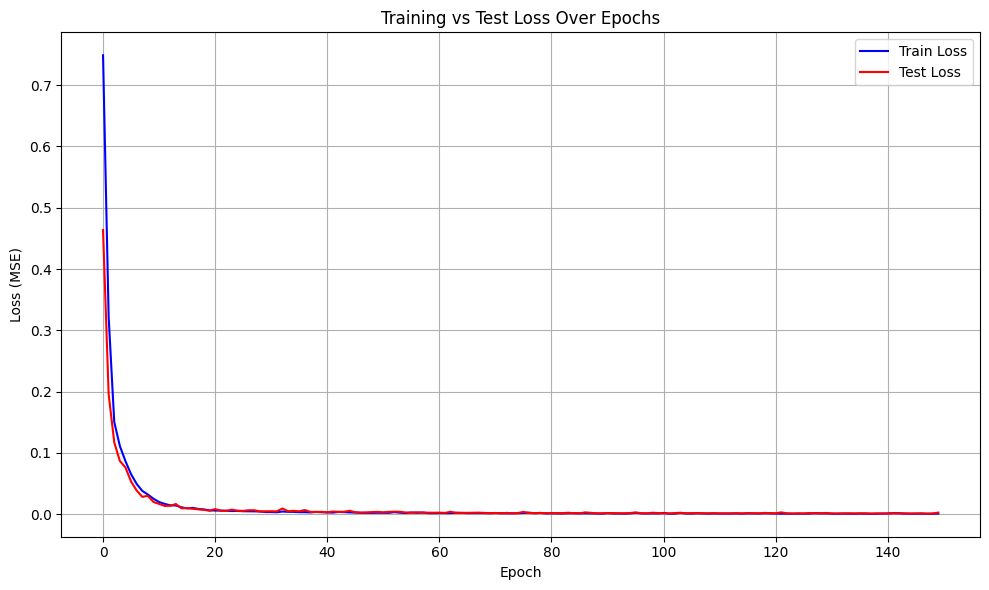

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='Train Loss', color='blue')
plt.plot(test_losses, label='Test Loss', color='red')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title('Training vs Test Loss Over Epochs')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [14]:
y_true = y_test[seq_len - 1:]

# بازگرداندن مقیاس استانداردسازی برای مقایسه‌ی دقیق
y_pred_inv = scaler_y.inverse_transform(preds)
y_true_inv = scaler_y.inverse_transform(y_true)

In [15]:
results = pd.DataFrame({
    'Actual MoleFractionTX': y_true_inv[:, 0],
    'Predicted MoleFractionTX': y_pred_inv[:, 0],
    'Actual MoleFractionHX': y_true_inv[:, 1],
    'Predicted MoleFractionHX': y_pred_inv[:, 1]
})

print(results.head())

   Actual MoleFractionTX  Predicted MoleFractionTX  Actual MoleFractionHX  \
0               0.938403                  0.938227               0.959166   
1               0.943601                  0.944440               0.968409   
2               0.936511                  0.936839               0.965961   
3               0.988175                  0.988862               0.994014   
4               0.936486                  0.936249               0.965970   

   Predicted MoleFractionHX  
0                  0.958909  
1                  0.969594  
2                  0.966355  
3                  0.992812  
4                  0.966786  


In [16]:
def percentage_within_tolerance(y_true, y_pred, tolerance):
    diff = np.abs(y_true - y_pred)
    within_tol = np.sum(diff <= tolerance)
    return (within_tol / len(y_true)) * 100

In [17]:
tolerances = [0.005, 0.002, 0.001]

# دو خروجی داریم: TX (ستون 0) و HX (ستون 1)
tx_true = y_true_inv[:, 0]
tx_pred = y_pred_inv[:, 0]
hx_true = y_true_inv[:, 1]
hx_pred = y_pred_inv[:, 1]

tx_results = []
hx_results = []

In [18]:
for tol in tolerances:
    tx_acc = percentage_within_tolerance(tx_true, tx_pred, tolerance=tol)
    hx_acc = percentage_within_tolerance(hx_true, hx_pred, tolerance=tol)
    tx_results.append(tx_acc)
    hx_results.append(hx_acc)
    print(f"TX - درصد پیش‌بینی‌ها با اختلاف ≤ ±{tol}: {tx_acc:.2f}%")
    print(f"HX - درصد پیش‌بینی‌ها با اختلاف ≤ ±{tol}: {hx_acc:.2f}%")
    print('-'*50)

TX - درصد پیش‌بینی‌ها با اختلاف ≤ ±0.005: 99.44%
HX - درصد پیش‌بینی‌ها با اختلاف ≤ ±0.005: 99.20%
--------------------------------------------------
TX - درصد پیش‌بینی‌ها با اختلاف ≤ ±0.002: 95.26%
HX - درصد پیش‌بینی‌ها با اختلاف ≤ ±0.002: 94.15%
--------------------------------------------------
TX - درصد پیش‌بینی‌ها با اختلاف ≤ ±0.001: 90.33%
HX - درصد پیش‌بینی‌ها با اختلاف ≤ ±0.001: 82.52%
--------------------------------------------------


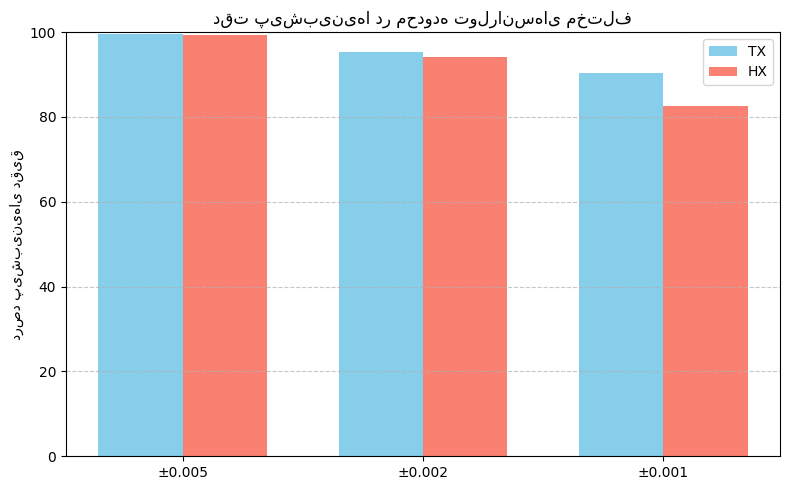

In [19]:
import matplotlib.pyplot as plt
x_labels = [f"±{tol}" for tol in tolerances]
x = np.arange(len(tolerances))

plt.figure(figsize=(8, 5))
bar_width = 0.35

plt.bar(x - bar_width/2, tx_results, width=bar_width, label='TX', color='skyblue')
plt.bar(x + bar_width/2, hx_results, width=bar_width, label='HX', color='salmon')

plt.xticks(x, x_labels)
plt.ylim(0, 100)
plt.ylabel("درصد پیش‌بینی‌های دقیق")
plt.title("دقت پیش‌بینی‌ها در محدوده تولرانس‌های مختلف")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [20]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

mse = mean_squared_error(y_true_inv, y_pred_inv)
mae = mean_absolute_error(y_true_inv, y_pred_inv)
r2 = r2_score(y_true_inv, y_pred_inv)

In [21]:
print(f"MSE: {mse}")
print(f"MAE: {mae}")
print(f"R2 Score: {r2}")

MSE: 1.6806547461989062e-06
MAE: 0.0005774710775457875
R2 Score: 0.997385648642403


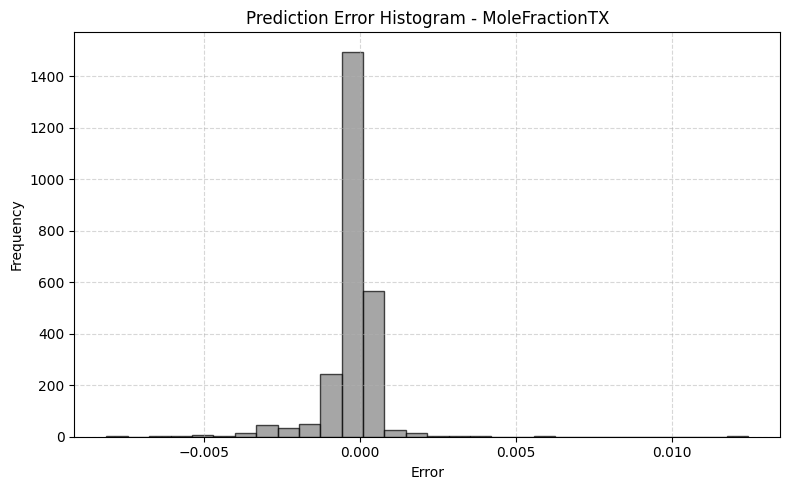

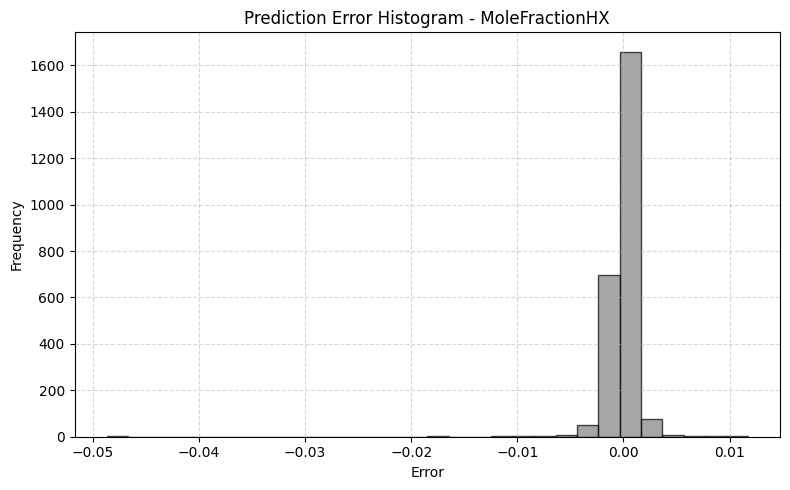

In [22]:
errors = y_true_inv - y_pred_inv
labels = ['TX', 'HX']

for i in range(2):
    plt.figure(figsize=(8, 5))
    plt.hist(errors[:, i], bins=30, color='gray', edgecolor='black', alpha=0.7)
    plt.title(f'Prediction Error Histogram - MoleFraction{labels[i]}')
    plt.xlabel('Error')
    plt.ylabel('Frequency')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

Total number of samples: 2512
Plotting first 5000 samples.


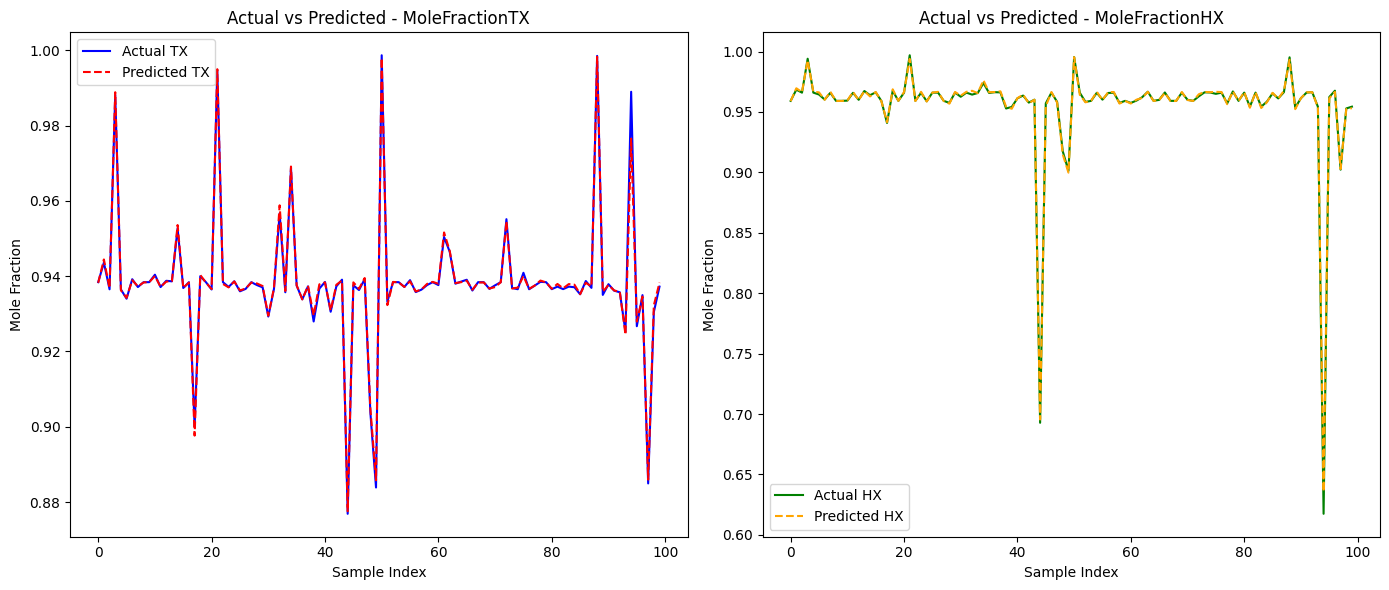

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

# بررسی تعداد کل داده‌ها
num_samples = len(results)
print(f"Total number of samples: {num_samples}")

# اگر داده‌ها بیشتر از 5000 بودند، فقط 5000 تای اول را انتخاب کن
if num_samples >= 100:
    subset = results.iloc[:100]
    print("Plotting first 5000 samples.")
else:
    subset = results
    print("Plotting all available samples.")

# رسم نمودار
plt.figure(figsize=(14, 6))

# MoleFractionTX
plt.subplot(1, 2, 1)
plt.plot(subset['Actual MoleFractionTX'].values, label='Actual TX', color='blue')
plt.plot(subset['Predicted MoleFractionTX'].values, label='Predicted TX', color='red', linestyle='--')
plt.title('Actual vs Predicted - MoleFractionTX')
plt.xlabel('Sample Index')
plt.ylabel('Mole Fraction')
plt.legend()

# MoleFractionHX
plt.subplot(1, 2, 2)
plt.plot(subset['Actual MoleFractionHX'].values, label='Actual HX', color='green')
plt.plot(subset['Predicted MoleFractionHX'].values, label='Predicted HX', color='orange', linestyle='--')
plt.title('Actual vs Predicted - MoleFractionHX')
plt.xlabel('Sample Index')
plt.ylabel('Mole Fraction')
plt.legend()

plt.tight_layout()
plt.show()